# Analyse sur les truites de notre échantillon dans le but de généraliser à la population

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

from utils.calcul_volume_fct import calculate_volumes, calculate_eggs_volumes, calculate_eggs_areas
from utils.stats_fct import distribution, nuage_points, linear_regression, plot_evolution_curves

In [2]:
# ---- Importation du fichier avec les metadatas ----
file_path = '../utils/correspondance_echo_final.xlsx'
df = pd.read_excel(file_path, dtype={"image_id": str})

unique_id = np.unique(df.cap_id)

## Masques réels

### Récupère le vrai volume des gonades et des oeufs de l'échantillon

In [3]:
all_resultats_cavite = []
all_resultats_oeufs = []
surfaces_eggs_list = []

# --- Calcul des volumes par poisson ----
for id in unique_id:
    # On récupère les échographies associées au poisson
    echos_poisson = df[df.cap_id == id]
    
    # Calcul des volumes
    res_poisson_cavite = calculate_volumes(echos_poisson, id, "data/labels/YOLO/cavite/") # "data/labels/YOLO/cavite/" ou "U-NET/masks/3_classes/true_"
    res_poisson_oeufs, surfaces_all = calculate_eggs_volumes(echos_poisson, id, "data/labels/YOLO/oeufs/") # "data/labels/YOLO/oeufs/" ou "U-NET/masks/3_classes/true_"
    
    # On convertit le dict du poisson en DataFrame et on l'ajoute à la liste globale
    all_resultats_cavite.append(pd.DataFrame(res_poisson_cavite))
    all_resultats_oeufs.append(pd.DataFrame(res_poisson_oeufs))
    surfaces_eggs_list.extend(surfaces_all)

# On fusionne tous les résultats en un seul DataFrame final
df_res_true = pd.concat(all_resultats_cavite + all_resultats_oeufs, ignore_index=True)
df_res_true = df_res_true.sort_values(by=['id poisson', 'position echo'])
df_res_true.to_csv("true_volumes_ech.csv", index=False) # Sauvegarde du DataFrame en CSV

Position de l'écho : 1.0, surface gonades : 0.41 cm2, rayon : 0.36 cm, surface cavité : 1.34 cm2
Position de l'écho : 3.0, surface gonades : 0.43 cm2, rayon : 0.37 cm, surface cavité : 1.09 cm2
Position de l'écho : 4.0, surface gonades : 0.26 cm2, rayon : 0.29 cm, surface cavité : 0.56 cm2
Poisson n°: 356302, Nombre d'échos : 3/3, Volume total gonades: 1.59 cm3, volume total cavité: 4.27 cm3
-----------------------
Echo n° : 1, surface oeufs : 3.148 mm², rayon : 1.001 mm, volume : 4.2012 mm³
Poisson n°: 356302, Nombre d'échos : 1/1, Volume moyen oeufs: 4.2012 mm³
-----------------------
Position de l'écho : 0.0, surface gonades : 0.74 cm2, rayon : 0.48 cm, surface cavité : 1.68 cm2
Position de l'écho : 2.0, surface gonades : 1.17 cm2, rayon : 0.61 cm, surface cavité : 1.89 cm2
Position de l'écho : 4.0, surface gonades : 0.99 cm2, rayon : 0.56 cm, surface cavité : 1.13 cm2
Position de l'écho : 6.0, surface gonades : 0.41 cm2, rayon : 0.36 cm, surface cavité : 0.60 cm2
Poisson n°: 356418

In [4]:
# ----- 1. Fusionne les données des échographies avec celles des poissons ----
df_res_true["id poisson"] = df_res_true["id poisson"].astype(str)
df_res_true = pd.merge(df_res_true, df[[ "image_id", "poids_poisson", "long_poisson", "age_poisson" ]], on="image_id", how="left")

# ----- 2. Divise les données entre les poissons et les œufs ----
df_true_fish = df_res_true[df_res_true["position echo"] != "œufs"]
df_true_eggs = df_res_true[df_res_true["position echo"] == "œufs"]

# ----- 3. Divise les données selon la position de l'écho ----
df_debut = df_true_fish[df_true_fish['position echo'] < 2]
df_fin = df_true_fish[df_true_fish['position echo'] >= 2]

# ----- 4. Jeu de données final avec uniquement les volumes  -----
df_final_true = df_res_true[["id poisson", "image_id" , "volume_cavite", "volume_gonade", "echelle", "volume_moyen_oeufs_mm3", 
                        "poids_poisson", "long_poisson", "age_poisson"]].groupby('id poisson', as_index=False).last()
df_final_true = df_final_true.dropna(subset=["volume_cavite"])

#------ 5. Calcul et ajout de la fécondité -------
df_final_true["fecondite"] = (df_final_true["volume_gonade"] * 1000) / df_final_true["volume_moyen_oeufs_mm3"]

In [5]:
df_final_true

,id poisson,image_id,volume_cavite,volume_gonade,echelle,volume_moyen_oeufs_mm3,poids_poisson,long_poisson,age_poisson,fecondite
0,356302,0004575,4.269466,1.585980,3.1,4.201180,65.6,176,None,377.508214
1,356418,0004585,8.699849,5.726512,3.8,8.717891,95.7,205,2+,656.868931
2,356430,0004591,11.526833,7.487346,3.8,10.287719,128.9,223,2+,727.794585
3,356434,0004596,11.473188,7.174567,3.8,6.551308,116.3,212,None,1095.135040
4,356859,0004646,6.613133,3.677799,3.8,7.892139,126.0,230,2+,466.007906
5,356868,0004650,8.886835,5.234275,3.8,8.887766,85.8,202,2+,588.930377
6,356877,0004656,2.116932,1.112477,3.8,2.365129,39.1,147,1+,470.366156
7,356918,0004663,6.104026,1.017180,3.8,2.595472,62.1,163,1+,391.905598
8,356948,0004671,10.477818,5.458090,3.8,8.229970,116.5,225,2+,663.196865
9,356970,0004678,5.586036,1.909926,3.8,2.392526,68.7,188,1+,798.288738


### Graphiques pour visualiser l'évolution de la surface des gonades pour un meme poisson

In [6]:
#Compter le nombre de lignes par poisson
poisson_counts = df_true_fish['id poisson'].value_counts()

# Filtrer les poissons avec exactement 2 lignes
poissons_2_lines = poisson_counts[poisson_counts == 2].index
df_2_lines = df_true_fish[df_true_fish['id poisson'].isin(poissons_2_lines)]

# Filtrer les poissons avec plus de 2 lignes
poissons_other = poisson_counts[poisson_counts > 2].index
df_other = df_true_fish[df_true_fish['id poisson'].isin(poissons_other)]

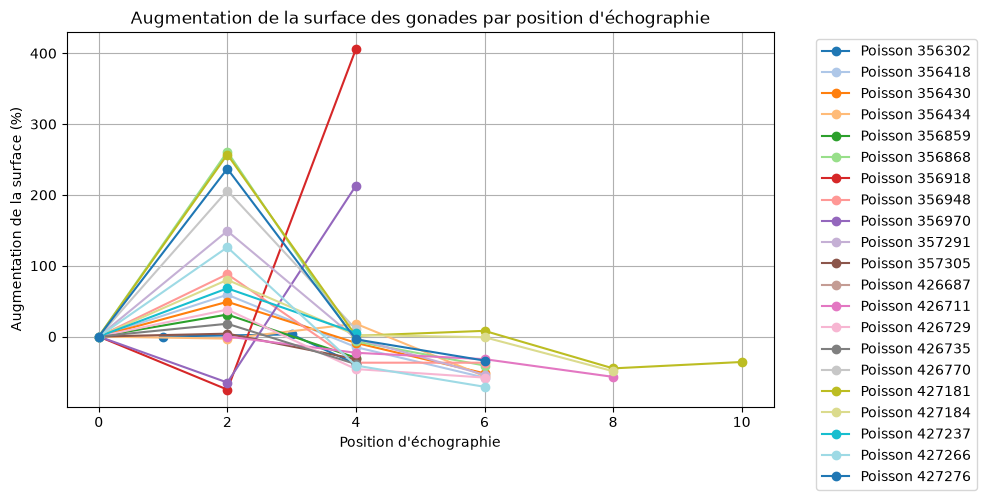

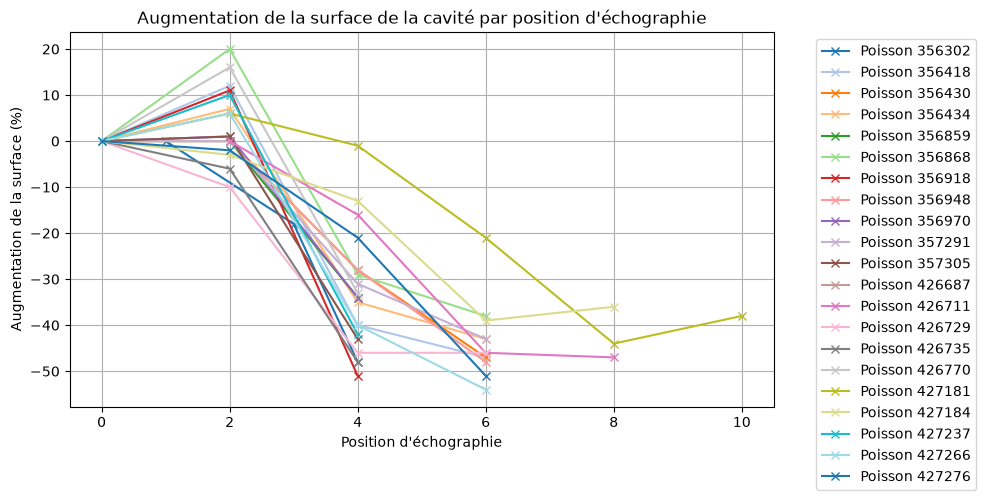

In [7]:
plot_evolution_curves(df_other)

### Graphique pour voir le lien entre la cavité et la gonade

Corrélation : 0.6318795889308401


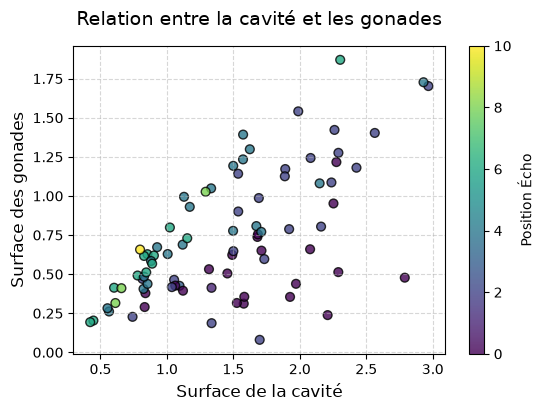

In [9]:
print(f"Corrélation : {df_true_fish.surface_cavite.corr(df_true_fish.surface_gonade)}") # Corrélation

nuage_points(
    x=df_true_fish.surface_cavite, 
    y=df_true_fish.surface_gonade,
    color_var=df_true_fish['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

Corrélation : 0.3950918948666595


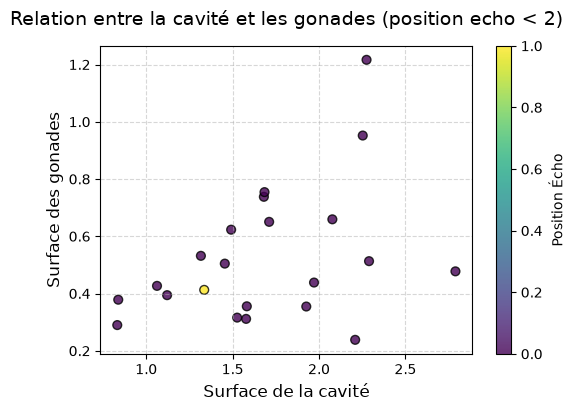

In [11]:
print(f"Corrélation : {df_debut.surface_cavite.corr(df_debut.surface_gonade)}") # Corrélation

nuage_points(
    x=df_debut.surface_cavite, 
    y=df_debut.surface_gonade,
    color_var=df_debut['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades (position echo < 2)", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

Corrélation : 0.8154546949745247


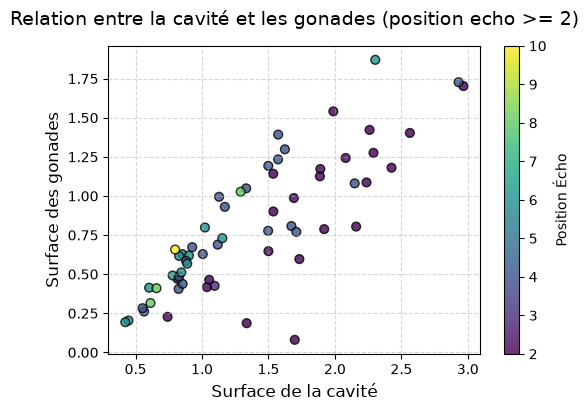

In [13]:
print(f"Corrélation : {df_fin.surface_cavite.corr(df_fin.surface_gonade)}") # Corrélation

nuage_points(
    x=df_fin.surface_cavite, 
    y=df_fin.surface_gonade,
    color_var=df_fin['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades (position echo >= 2)", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

### Détection des anomalies

In [ ]:
for id in df_true_fish['id poisson'].unique():
    rows = df_true_fish[df_true_fish['id poisson'] == id]
    nb_rows = len(rows)
    pb_list = []

    # Détection des potentiels problèmes de surfaces pour des poissons avec plus de 2 échos
    if nb_rows > 2:
        for i in range(nb_rows):
            # Si l'écho est à Op+2, alors elle ne doit pas avoir une augmentation négative de la surface des gonades
            if rows.iloc[i]["position echo"]==2.0:
                value = rows.iloc[i].augmentation_surface_gonade
                if value < -10 : # Tolerance de 10% pour les diminutions de surface des gonades
                    pb_list.append(1)
                else:
                    pb_list.append(0)

            # Si l'écho est à Op+3 ou plus, alors elle ne doit pas avoir une augmentation de la surface des gonades supérieure à 10%
            elif rows.iloc[i]["position echo"]>2.0:
                value = rows.iloc[i].augmentation_surface_gonade
                if value > 10 : # Tolerance de 10% pour les augmentations de surface des gonades
                    pb_list.append(1)
                else:
                    pb_list.append(0)
            else:
                pb_list.append(0)


        for i in range(len(pb_list)-1):
            # Si il y a deux "1" à la suite, alors l'erreur est sur la première échographie où il y a un "1"
            if pb_list[i] == 1 and pb_list[i+1] == 1:
                print(f"Poisson : {id} - Problèmes : {pb_list}")
                print(f"Poisson : {id} - Problème sur l'écho à la position {rows.iloc[i]['position echo']} (diminution surface gonade : {rows.iloc[i]['augmentation_surface_gonade']})")
                break
        # Si il y a un "1" seul à la deuxième position, alors l'erreur est sur la première échographie
        if pb_list[1] == 1 and pb_list[0] == 0 and pb_list[2] == 0:
            print(f"Poisson : {id} - Problèmes : {pb_list}")
            print(f"Poisson : {id} - Problème sur l'écho à la position {rows.iloc[0]['position echo']} (diminution surface gonade : {rows.iloc[0]['augmentation_surface_gonade']})")

Poisson : 356918 - Problèmes : [0, 1, 1]
Poisson : 356918 - Problème sur l'écho à la position 2.0 (diminution surface gonade : -75.0)
Poisson : 356970 - Problèmes : [0, 1, 1]
Poisson : 356970 - Problème sur l'écho à la position 2.0 (diminution surface gonade : -65.0)


## Graphique pour voir le lien entre la cavité/gonade.oeufs et le poisson taille/poids

### Rapport gonado-somatique : poids gonade / poids poisson * 100

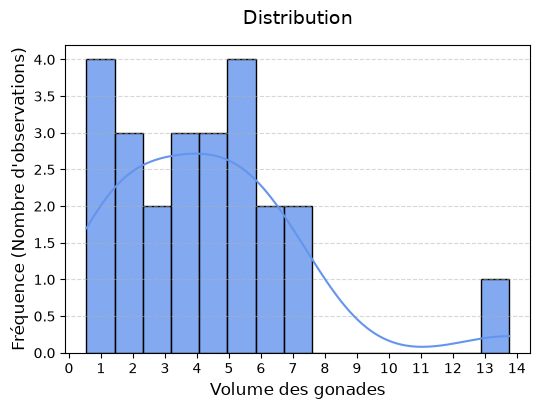

In [48]:
distribution(df_final_true.volume_gonade, xlabel = "Volume des gonades",nombre_graduations_x = 15,nombre_barres=15)

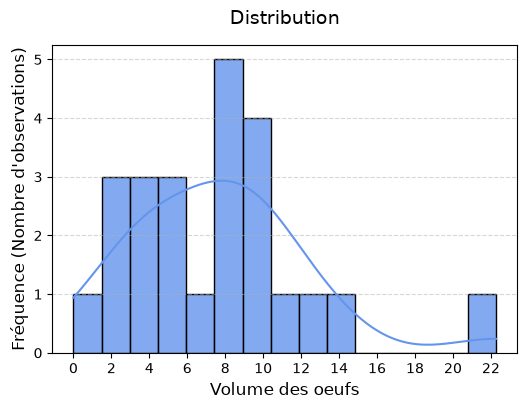

In [51]:
distribution(df_final_true.volume_moyen_oeufs_mm3, xlabel = "Volume des oeufs",nombre_graduations_x = 15,nombre_barres=15)

Est-ce que le rapport gonado somatique correspond à celui que l'on ait sensé avoir en octobre ?

### Relation poids/longueur poisson et volume gonade

Corrélation : 0.8212067670801009


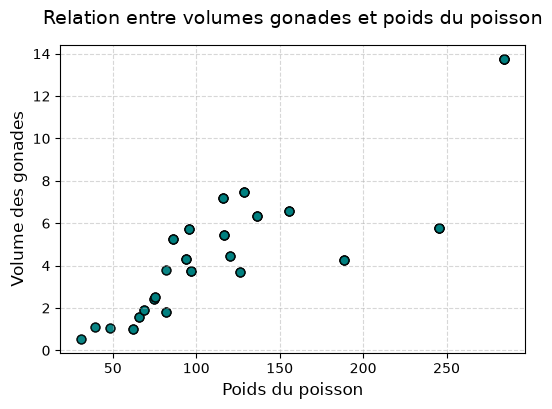

In [52]:
print(f"Corrélation : {df_true_fish.volume_gonade.corr(df_true_fish.poids_poisson)}") # Corrélation

nuage_points(
    x=df_true_fish.poids_poisson, # long_poisson ou poids_poisson
    y=df_true_fish.volume_gonade,
    titre="Relation entre volumes gonades et poids du poisson", 
    xlabel="Poids du poisson", 
    ylabel="Volume des gonades",
    couleur='teal'
    )

### Relation poids/longueur poisson et volume cavité

Corrélation : 0.9023430515428019


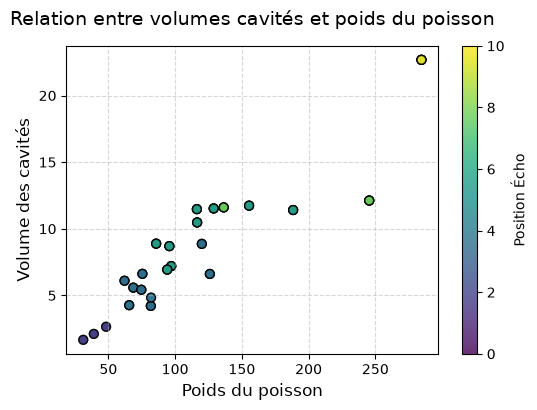

In [53]:
print(f"Corrélation : {df_true_fish.volume_cavite.corr(df_true_fish.poids_poisson)}") # Corrélation

nuage_points(
    x=df_true_fish.poids_poisson, # long_poisson ou poids_poisson
    y=df_true_fish.volume_cavite,
    color_var=df_true_fish['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre volumes cavités et poids du poisson", 
    xlabel="Poids du poisson", 
    ylabel="Volume des cavités",
    couleur='teal'
    )

## Analyse des résultats des oeufs distribution

### Distribution des volumes individuels par échographie

Les volumes sont recalculés pour chaque œuf segmenté afin de conserver l'identifiant de l'échographie. Les cellules suivantes sont indépendantes du calcul existant du volume moyen et de la fécondité.

In [17]:
# Récupération du volume individuel de chaque œuf avec son échographie d'origine
oeufs_individuels = []
df_echos_oeufs = df[df["type_image"] == "œufs"]

for _, echo in df_echos_oeufs.iterrows():
    mask_path = Path("../data/labels/YOLO/oeufs") / f"{echo['new_name_file']}.txt"
    image_path = Path("../data/images/oeufs") / f"{echo['new_name_file']}.jpg"

    if not mask_path.exists() or not image_path.exists() or pd.isna(echo["echelle"]):
        continue

    _, surfaces_oeufs_mm2 = calculate_eggs_areas(
        str(mask_path), str(image_path), echo["echelle"]
    )

    for surface_oeuf_mm2 in surfaces_oeufs_mm2:
        if surface_oeuf_mm2 <= 0:
            continue
        rayon_oeuf_mm = np.sqrt(surface_oeuf_mm2 / np.pi)
        volume_oeuf_mm3 = 4 / 3 * np.pi * rayon_oeuf_mm ** 3
        oeufs_individuels.append({
            "id poisson": str(echo["cap_id"]),
            "image_id": str(echo["image_id"]),
            "volume_oeuf_mm3": volume_oeuf_mm3,
        })

df_oeufs_individuels = pd.DataFrame(oeufs_individuels)
print(
    f"{len(df_oeufs_individuels)} œufs répartis dans "
    f"{df_oeufs_individuels['image_id'].nunique()} échographies non vides."
)

381 œufs répartis dans 59 échographies non vides.


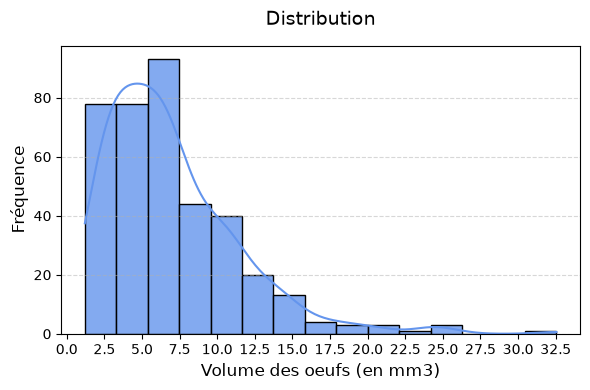

<Axes: title={'center': 'Distribution'}, xlabel='Volume des oeufs (en mm3)', ylabel='Fréquence'>

In [18]:
distribution(df_oeufs_individuels.volume_oeuf_mm3, xlabel = "Volume des oeufs (en mm3)",nombre_graduations_x = 15,nombre_barres=15)

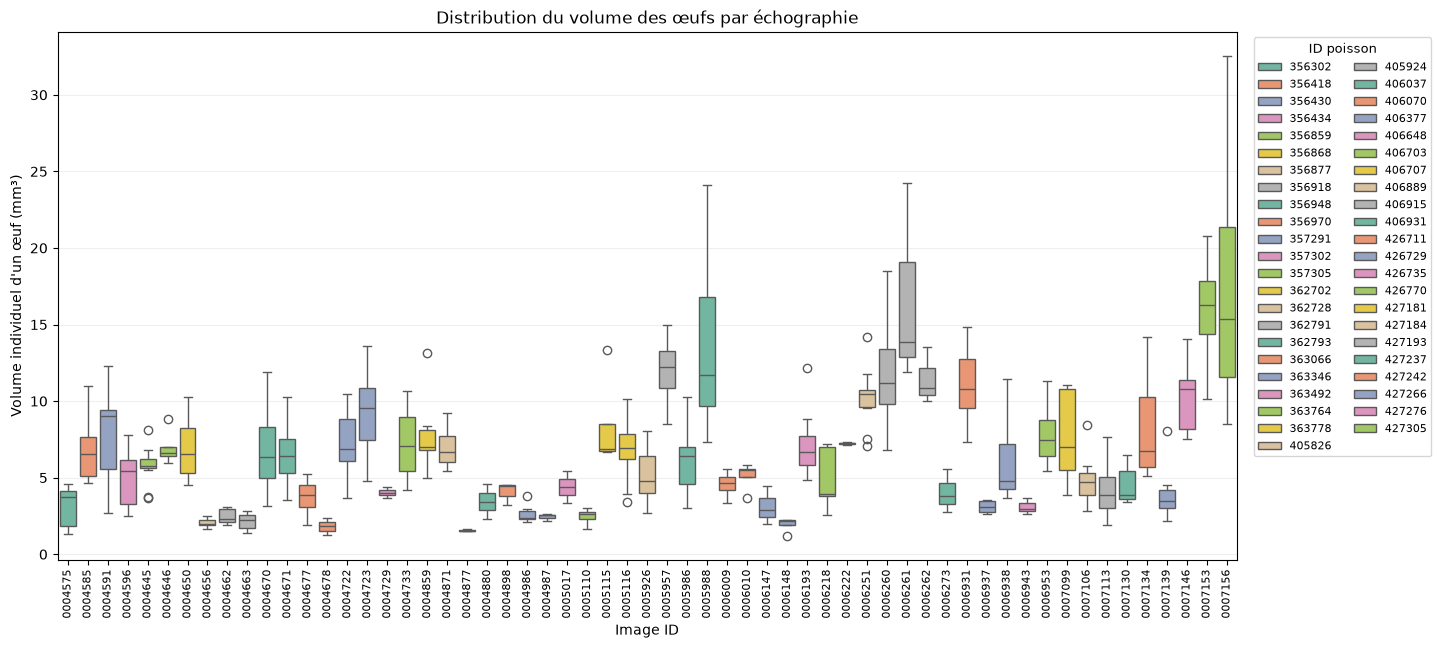

In [24]:
# Distribution des volumes individuels des œufs pour chaque échographie
ordre_images = sorted(df_oeufs_individuels["image_id"].unique())
ordre_poissons = sorted(df_oeufs_individuels["id poisson"].unique())
palette_poissons = dict(zip(
    ordre_poissons, sns.color_palette("Set2", n_colors=len(ordre_poissons))
))

fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=df_oeufs_individuels,
    x="image_id", y="volume_oeuf_mm3",
    hue="id poisson", order=ordre_images, hue_order=ordre_poissons,
    palette=palette_poissons, dodge=False, ax=ax,
)
ax.set(
    title="Distribution du volume des œufs par échographie",
    xlabel="Image ID",
    ylabel="Volume individuel d'un œuf (mm³)",
)
ax.tick_params(axis="x", labelrotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.2)
fig.subplots_adjust(right=0.78, bottom=0.22)
ax.legend(
    title="ID poisson", bbox_to_anchor=(1.01, 1), loc="upper left",
    ncol=2, fontsize=8, title_fontsize=9
)
plt.show()

### Nombre et proportion d'œufs extrêmes par échographie

Un œuf est considéré comme extrême lorsque son volume est inférieur à `Q1 - 1,5 × IQR` ou supérieur à `Q3 + 1,5 × IQR`. Les seuils sont calculés séparément pour chaque échographie.

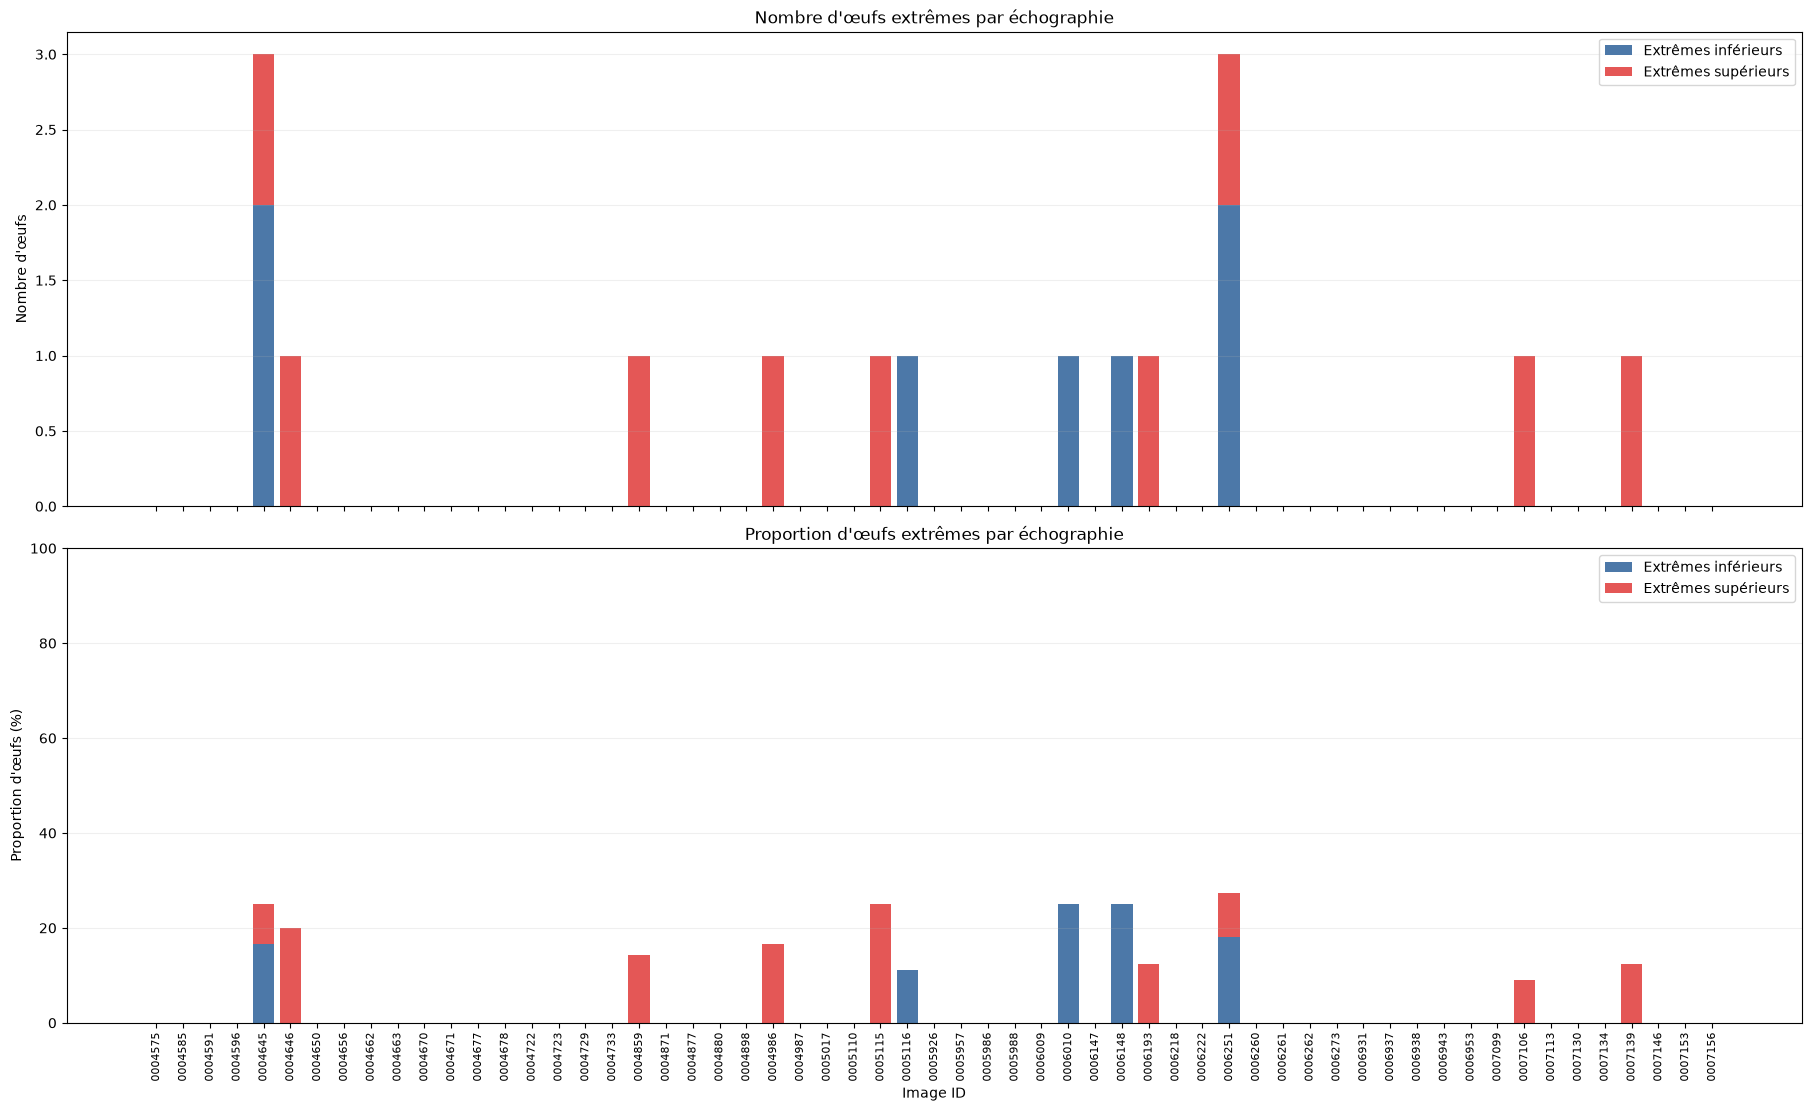

,nombre_oeufs,nombre_extremes_inferieurs,nombre_extremes_superieurs,proportion_extremes_inferieurs,proportion_extremes_superieurs
image_id,,,,,
0004575,9,0,0,0.000000,0.000000
0004585,7,0,0,0.000000,0.000000
0004591,9,0,0,0.000000,0.000000
0004596,9,0,0,0.000000,0.000000
0004645,12,2,1,16.666667,8.333333
0004646,5,0,1,0.000000,20.000000
0004650,4,0,0,0.000000,0.000000
0004656,5,0,0,0.000000,0.000000
0004662,8,0,0,0.000000,0.000000


In [26]:
# Identification des œufs extrêmes selon la règle du boxplot, par échographie
df_oeufs_individuels_extremes = df_oeufs_individuels.copy()
volumes_par_image = df_oeufs_individuels_extremes.groupby("image_id")["volume_oeuf_mm3"]

q1 = volumes_par_image.transform(lambda volumes: volumes.quantile(0.25))
q3 = volumes_par_image.transform(lambda volumes: volumes.quantile(0.75))
iqr = q3 - q1
df_oeufs_individuels_extremes["extreme_inferieur"] = (
    df_oeufs_individuels_extremes["volume_oeuf_mm3"] < q1 - 1.5 * iqr
)
df_oeufs_individuels_extremes["extreme_superieur"] = (
    df_oeufs_individuels_extremes["volume_oeuf_mm3"] > q3 + 1.5 * iqr
)

resume_extremes = (
    df_oeufs_individuels_extremes.groupby("image_id")
    .agg(
        nombre_oeufs=("volume_oeuf_mm3", "size"),
        nombre_extremes_inferieurs=("extreme_inferieur", "sum"),
        nombre_extremes_superieurs=("extreme_superieur", "sum"),
    )
    .reindex(ordre_images)
)
resume_extremes["proportion_extremes_inferieurs"] = (
    100 * resume_extremes["nombre_extremes_inferieurs"] / resume_extremes["nombre_oeufs"]
)
resume_extremes["proportion_extremes_superieurs"] = (
    100 * resume_extremes["nombre_extremes_superieurs"] / resume_extremes["nombre_oeufs"]
)

positions = np.arange(len(resume_extremes))
couleurs_extremes = {"Inférieurs": "#4C78A8", "Supérieurs": "#E45756"}
fig, (ax_nombres, ax_proportions) = plt.subplots(
    2, 1, figsize=(18, 11), sharex=True, constrained_layout=True
)

ax_nombres.bar(
    positions, resume_extremes["nombre_extremes_inferieurs"],
    color=couleurs_extremes["Inférieurs"], label="Extrêmes inférieurs",
)
ax_nombres.bar(
    positions, resume_extremes["nombre_extremes_superieurs"],
    bottom=resume_extremes["nombre_extremes_inferieurs"],
    color=couleurs_extremes["Supérieurs"], label="Extrêmes supérieurs",
)
ax_nombres.set(
    title="Nombre d'œufs extrêmes par échographie",
    ylabel="Nombre d'œufs",
)

ax_proportions.bar(
    positions, resume_extremes["proportion_extremes_inferieurs"],
    color=couleurs_extremes["Inférieurs"], label="Extrêmes inférieurs",
)
ax_proportions.bar(
    positions, resume_extremes["proportion_extremes_superieurs"],
    bottom=resume_extremes["proportion_extremes_inferieurs"],
    color=couleurs_extremes["Supérieurs"], label="Extrêmes supérieurs",
)
ax_proportions.set(
    title="Proportion d'œufs extrêmes par échographie",
    xlabel="Image ID",
    ylabel="Proportion d'œufs (%)",
)
ax_proportions.set_ylim(0, 100)
ax_proportions.set_xticks(positions, resume_extremes.index, rotation=90, fontsize=8)

for ax in (ax_nombres, ax_proportions):
    ax.grid(axis="y", alpha=0.2)
    ax.legend(loc="upper right")

plt.show()
resume_extremes

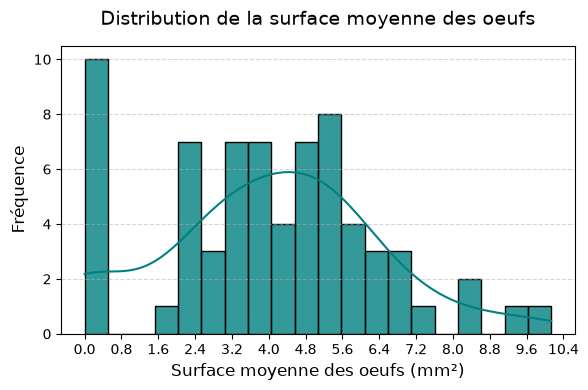

[ 0.          0.          2.46243526  3.93451686  5.37640657  7.91695342
 10.13456945]


In [22]:
distribution(df_true_eggs.surface_moyenne_oeufs_mm2, "Distribution de la surface moyenne des oeufs", "Surface moyenne des oeufs (mm²)", couleur='teal', nombre_graduations_x = 15,nombre_barres=20)
print(np.quantile(df_true_eggs.surface_moyenne_oeufs_mm2, q = (0, 0.05, 0.25, 0.5, 0.75, 0.95, 1))) # Affiche les quantiles de la surface moyenne des oeufs en mm²

### Relation volume des oeufs et poids/longueur poisson

In [57]:
df_true_eggs[df_true_eggs.poids_poisson > 350]

,id poisson,image_id,position echo,surface_cavite,surface_gonade,volume_cavite,volume_gonade,echelle,augmentation_surface_gonade,augmentation_surface_cavite,surface_moyenne_oeufs_mm2,volume_moyen_oeufs_mm3,poids_poisson,long_poisson,age_poisson
70,363346,0004986,œufs,NaN,NaN,NaN,NaN,3.1,NaN,NaN,2.538132,3.041832,401.9,325,4+34
71,363346,0004987,œufs,NaN,NaN,NaN,NaN,3.1,NaN,NaN,2.297368,2.619448,401.9,325,4+34


Corrélation : 0.24554836481306733


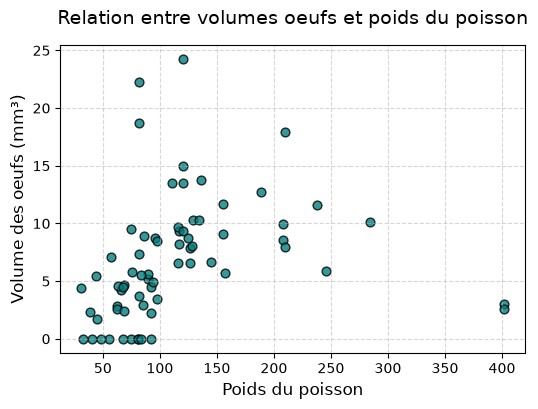

In [58]:
print(f"Corrélation : {df_true_eggs.volume_moyen_oeufs_mm3.corr(df_true_eggs.poids_poisson)}") # Corrélation

nuage_points(
    x=df_true_eggs.poids_poisson, # long_poisson ou poids_poisson
    y=df_true_eggs.volume_moyen_oeufs_mm3,
    titre="Relation entre volumes oeufs et poids du poisson", 
    xlabel="Poids du poisson", 
    ylabel="Volume des oeufs (mm³)",
    couleur='teal'
    )

### Relation volume des oeufs et volume/longueur gonade/poisson

Corrélation : 0.4578773466799313


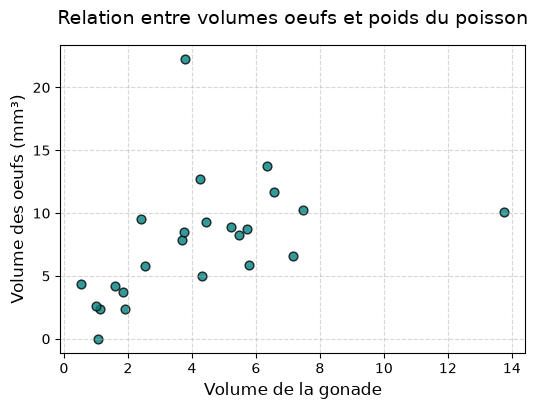

In [59]:
print(f"Corrélation : {df_final_true.volume_moyen_oeufs_mm3.corr(df_final_true.volume_gonade)}") # Corrélation

nuage_points(
    x=df_final_true.volume_gonade, # long_poisson ou poids_poisson
    y=df_final_true.volume_moyen_oeufs_mm3,
    titre="Relation entre volumes oeufs et poids du poisson", 
    xlabel="Volume de la gonade", 
    ylabel="Volume des oeufs (mm³)",
    couleur='teal'
    )

### Distribution de la fécondité

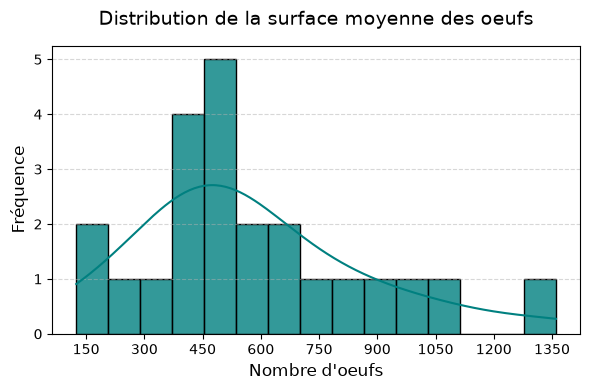

[ 124.61596892  182.3146871   427.95579669  486.38626459  745.41812347
 1320.48862857           nan]


/home/ldepiero/Stage-GonAIde-2026/mon_venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [25]:
distribution(df_final_true.fecondite, "Distribution de la surface moyenne des oeufs", "Nombre d'oeufs", couleur='teal', bins=15, nombre_graduations_x = 10)
print(np.quantile(df_final_true.fecondite, q = (0, 0.05, 0.25, 0.5, 0.75, 0.95, 1))) # Affiche les quantiles de la surface moyenne des oeufs

### Relation fécondite / poisson

Corrélation : nan


/home/ldepiero/Stage-GonAIde-2026/mon_venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/home/ldepiero/Stage-GonAIde-2026/mon_venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


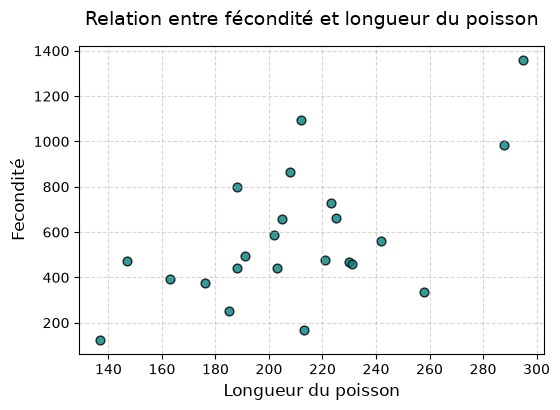

In [64]:
print(f"Corrélation : {df_final_true.fecondite.corr(df_final_true.long_poisson)}") # Corrélation

nuage_points(
    x=df_final_true.long_poisson, # long_poisson ou poids_poisson
    y=df_final_true.fecondite,
    titre="Relation entre fécondité et longueur du poisson", 
    xlabel="Longueur du poisson", 
    ylabel="Fecondité",
    couleur='teal'
    )

## Masques prédits

### Récupère le volume prédits des gonades de l'échantillon

In [ ]:
def index_predictions(mask_dir):
    """Indexe les images disposant d'une prédiction pred_<image>.txt."""
    predictions = set()
    for mask_path in sorted(mask_dir.glob("pred_*.txt")):
        if mask_path.name.startswith("pred_fold_"):
            raise ValueError(f"Ancien nom de prédiction : {mask_path.name}")
        image_name = mask_path.stem.removeprefix("pred_")
        if image_name in predictions:
            raise ValueError(f"Plusieurs prédictions trouvées pour {image_name}")
        predictions.add(image_name)
    return predictions


def complete_missing_volumes(results, echos_poisson):
    """Complète les volumes quand toutes les gonades prédites sont vides."""
    row_count = len(results["image_id"])
    if not row_count or all(
        len(results[column]) == row_count
        for column in ("volume_cavite", "volume_gonade")
    ):
        return results

    positions = np.asarray(results["position echo"], dtype=float)
    last_image_id = results["image_id"][-1]
    long_gonade = echos_poisson.loc[
        echos_poisson["image_id"] == last_image_id, "long_gonade"
    ].iloc[-1]

    for surface_column, volume_column in (
        ("surface_cavite", "volume_cavite"),
        ("surface_gonade", "volume_gonade"),
    ):
        radii = np.sqrt(np.asarray(results[surface_column], dtype=float) / np.pi)
        segments = []
        if positions[0] > 0:
            segments.append(np.pi * radii[0] ** 2 * positions[0] / 3)
        for index in range(1, row_count):
            distance = positions[index] - positions[index - 1]
            segments.append(
                np.pi / 3 * distance * (
                    radii[index - 1] ** 2 + radii[index] ** 2
                    + radii[index - 1] * radii[index]
                )
            )
        segments.append(
            np.pi * radii[-1] ** 2 * abs(positions[-1] - long_gonade) / 3
        )
        total_volume = float(np.sum(segments))
        results[volume_column] = [total_volume] * row_count
    return results


cavity_masks_root = "UNet/masks/eval/UNet/3classes"
egg_masks_root = "YOLO26/masks/eval/instance/oeufs"
cavity_predictions = index_predictions(Path("..") / cavity_masks_root)
egg_predictions = index_predictions(Path("..") / egg_masks_root)

all_resultats_cavite = []
all_resultats_oeufs = []

# --- Calcul des volumes par poisson ----
for id in unique_id:
    # On récupère les échographies associées au poisson
    echos_poisson = df[df.cap_id == id].copy()
    # Une surface prédite peut être nulle : les scalaires NumPy produisent alors
    # une variation NaN/inf sans interrompre le calcul des volumes suivants.
    echos_poisson["echelle"] = pd.Series(
        [np.float64(value) for value in echos_poisson["echelle"]],
        index=echos_poisson.index, dtype=object,
    )

    cavity_image_names = set(echos_poisson.loc[
        echos_poisson["type_image"] != "œufs", "new_name_file"
    ].astype(str))
    egg_image_names = set(echos_poisson.loc[
        echos_poisson["type_image"] == "œufs", "new_name_file"
    ].astype(str))

    if cavity_image_names & cavity_predictions:
        with np.errstate(divide="ignore", invalid="ignore"):
            res_poisson_cavite = calculate_volumes(
                echos_poisson, id, f"{cavity_masks_root}/pred_"
            )
        res_poisson_cavite = complete_missing_volumes(
            res_poisson_cavite, echos_poisson
        )
        all_resultats_cavite.append(pd.DataFrame(res_poisson_cavite))

    if egg_image_names & egg_predictions:
        res_poisson_oeufs, _ = calculate_eggs_volumes(
            echos_poisson, id, f"{egg_masks_root}/pred_"
        )
        all_resultats_oeufs.append(pd.DataFrame(res_poisson_oeufs))

# On fusionne tous les résultats en un seul DataFrame final
df_res_pred = pd.concat(all_resultats_cavite + all_resultats_oeufs, ignore_index=True)
df_res_pred = df_res_pred.sort_values(by=['id poisson', 'position echo'])
df_res_pred.to_csv("pred_volumes_ech.csv", index=False) # Sauvegarde du DataFrame en CSV

Position de l'écho : 1.0, surface gonades : 1.05 cm2, rayon : 0.58 cm, surface cavité : 2.24 cm2
Position de l'écho : 3.0, surface gonades : 1.08 cm2, rayon : 0.59 cm, surface cavité : 1.74 cm2
Position de l'écho : 4.0, surface gonades : 0.52 cm2, rayon : 0.41 cm, surface cavité : 0.89 cm2
Poisson n°: 356302, Nombre d'échos : 3/3, Volume total gonades: 3.79 cm3, volume total cavité: 6.94 cm3
-----------------------
Echo n° : 1, surface oeufs : 5.272 mm², rayon : 1.295 mm, volume : 9.1059 mm³
Poisson n°: 356302, Nombre d'échos : 1/1, Volume moyen oeufs: 9.1059 mm³
-----------------------
Position de l'écho : 0.0, surface gonades : 1.26 cm2, rayon : 0.63 cm, surface cavité : 2.78 cm2
Position de l'écho : 2.0, surface gonades : 1.84 cm2, rayon : 0.77 cm, surface cavité : 2.87 cm2
Position de l'écho : 4.0, surface gonades : 1.28 cm2, rayon : 0.64 cm, surface cavité : 1.78 cm2
Position de l'écho : 6.0, surface gonades : 0.72 cm2, rayon : 0.48 cm, surface cavité : 1.06 cm2
Poisson n°: 356418

In [ ]:
# ----- 1. Fusionne les données des échographies avec celles des poissons ----
df_res_pred["id poisson"] = df_res_pred["id poisson"].astype(str)
df_res_pred = pd.merge(df_res_pred, df[[ "image_id", "poids_poisson", "long_poisson", "age_poisson" ]], on="image_id", how="left")

# ----- 2. Jeu de données final avec uniquement les volumes  -----
df_final_pred = df_res_pred[["id poisson", "image_id" , "volume_cavite", "volume_gonade", "echelle", "volume_moyen_oeufs_mm3", 
                        "poids_poisson", "long_poisson", "age_poisson"]].groupby('id poisson', as_index=False).last()
df_final_pred = df_final_pred.dropna()

#------ 3. Calcul et ajout de la fécondité -------
df_final_pred["fecondite"] = (df_final_pred["volume_gonade"] * 1000) / df_final_pred["volume_moyen_oeufs_mm3"]

## Comparaison masque réel et masque prédit

In [26]:
# ----- Fusionne les données des masques réels des prédits ----
df_final = pd.merge(df_final_pred, df_final_true[[ "id poisson", "volume_cavite", "volume_gonade", "volume_moyen_oeufs_mm3", "fecondite" ]], on="id poisson", how="left")

In [27]:
df_final

,id poisson,image_id,volume_cavite_x,volume_gonade_x,echelle,volume_moyen_oeufs_x,poids_poisson,long_poisson,age_poisson,fecondite_x,volume_cavite_y,volume_gonade_y,volume_moyen_oeufs_y,fecondite_y
0,356430,0004591,18.624829,11.345090,3.8,0.008968,128.9,223,2+,1265.069221,11.526833,7.487346,0.008968,834.899601
1,356970,0004678,8.698973,3.368567,3.8,0.005866,68.7,188,1+,574.245158,5.586036,1.909926,0.005866,325.588278
2,427202,0007120,4.119726,1.636005,3.8,0.006539,48.3,163,2+,250.195718,2.652075,1.066571,0.006539,163.111558
3,427237,0007130,9.853986,4.804979,3.8,0.004519,75.5,188,1+,1063.364077,6.621964,2.543383,0.004519,562.862318
